LeNet-5
The First LeNet-5 architecture is the most widely known CNN architecture. It was introduced in 1998 and is widely used for handwritten method digit recognition.
 LeNet-5 has 2 convolutional and 3 full layers.
This LeNet-5 architecture has 60,000 parameters.

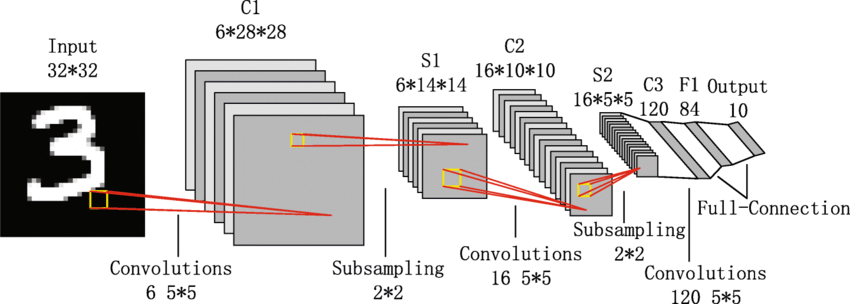

https://www.geeksforgeeks.org/convolutional-neural-network-cnn-architectures/

In [11]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

class LeNet5(nn.Module):
    """
    LeNet-5 model for image classification.
    Architecture:
    - Input: 32x32 color images
    - 2 Convolutional layers with ReLU and subsampling
    - 3 Fully connected layers
    - Output: 10 classes
    """
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, kernel_size=5, stride=1, padding=2)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 6 * 6, 120)  # Adjusted size based on CIFAR-10
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x


**AlexNNet**
The AlexNet CNN architecture won the 2012 ImageNet ILSVRC challenges of deep learning algorithm by a large variance by achieving 17% with top-5 error rate as the second best achieved 26%!
It was introduced by Alex Krizhevsky (name of founder), The Ilya Sutskever and Geoffrey Hinton are quite similar to LeNet-5, only much bigger and deeper and it was introduced first to stack convolutional layers directly on top of each other models, instead of stacking a pooling layer top of each on CN network convolutional layer.
AlexNNet has 60 million parameters as AlexNet has total 8 layers, 5 convolutional and 3 fully connected layers.
AlexNNet is first to execute (ReLUs) Rectified Linear Units as activation functions
it was the first CNN architecture that uses GPU to improve the performance.

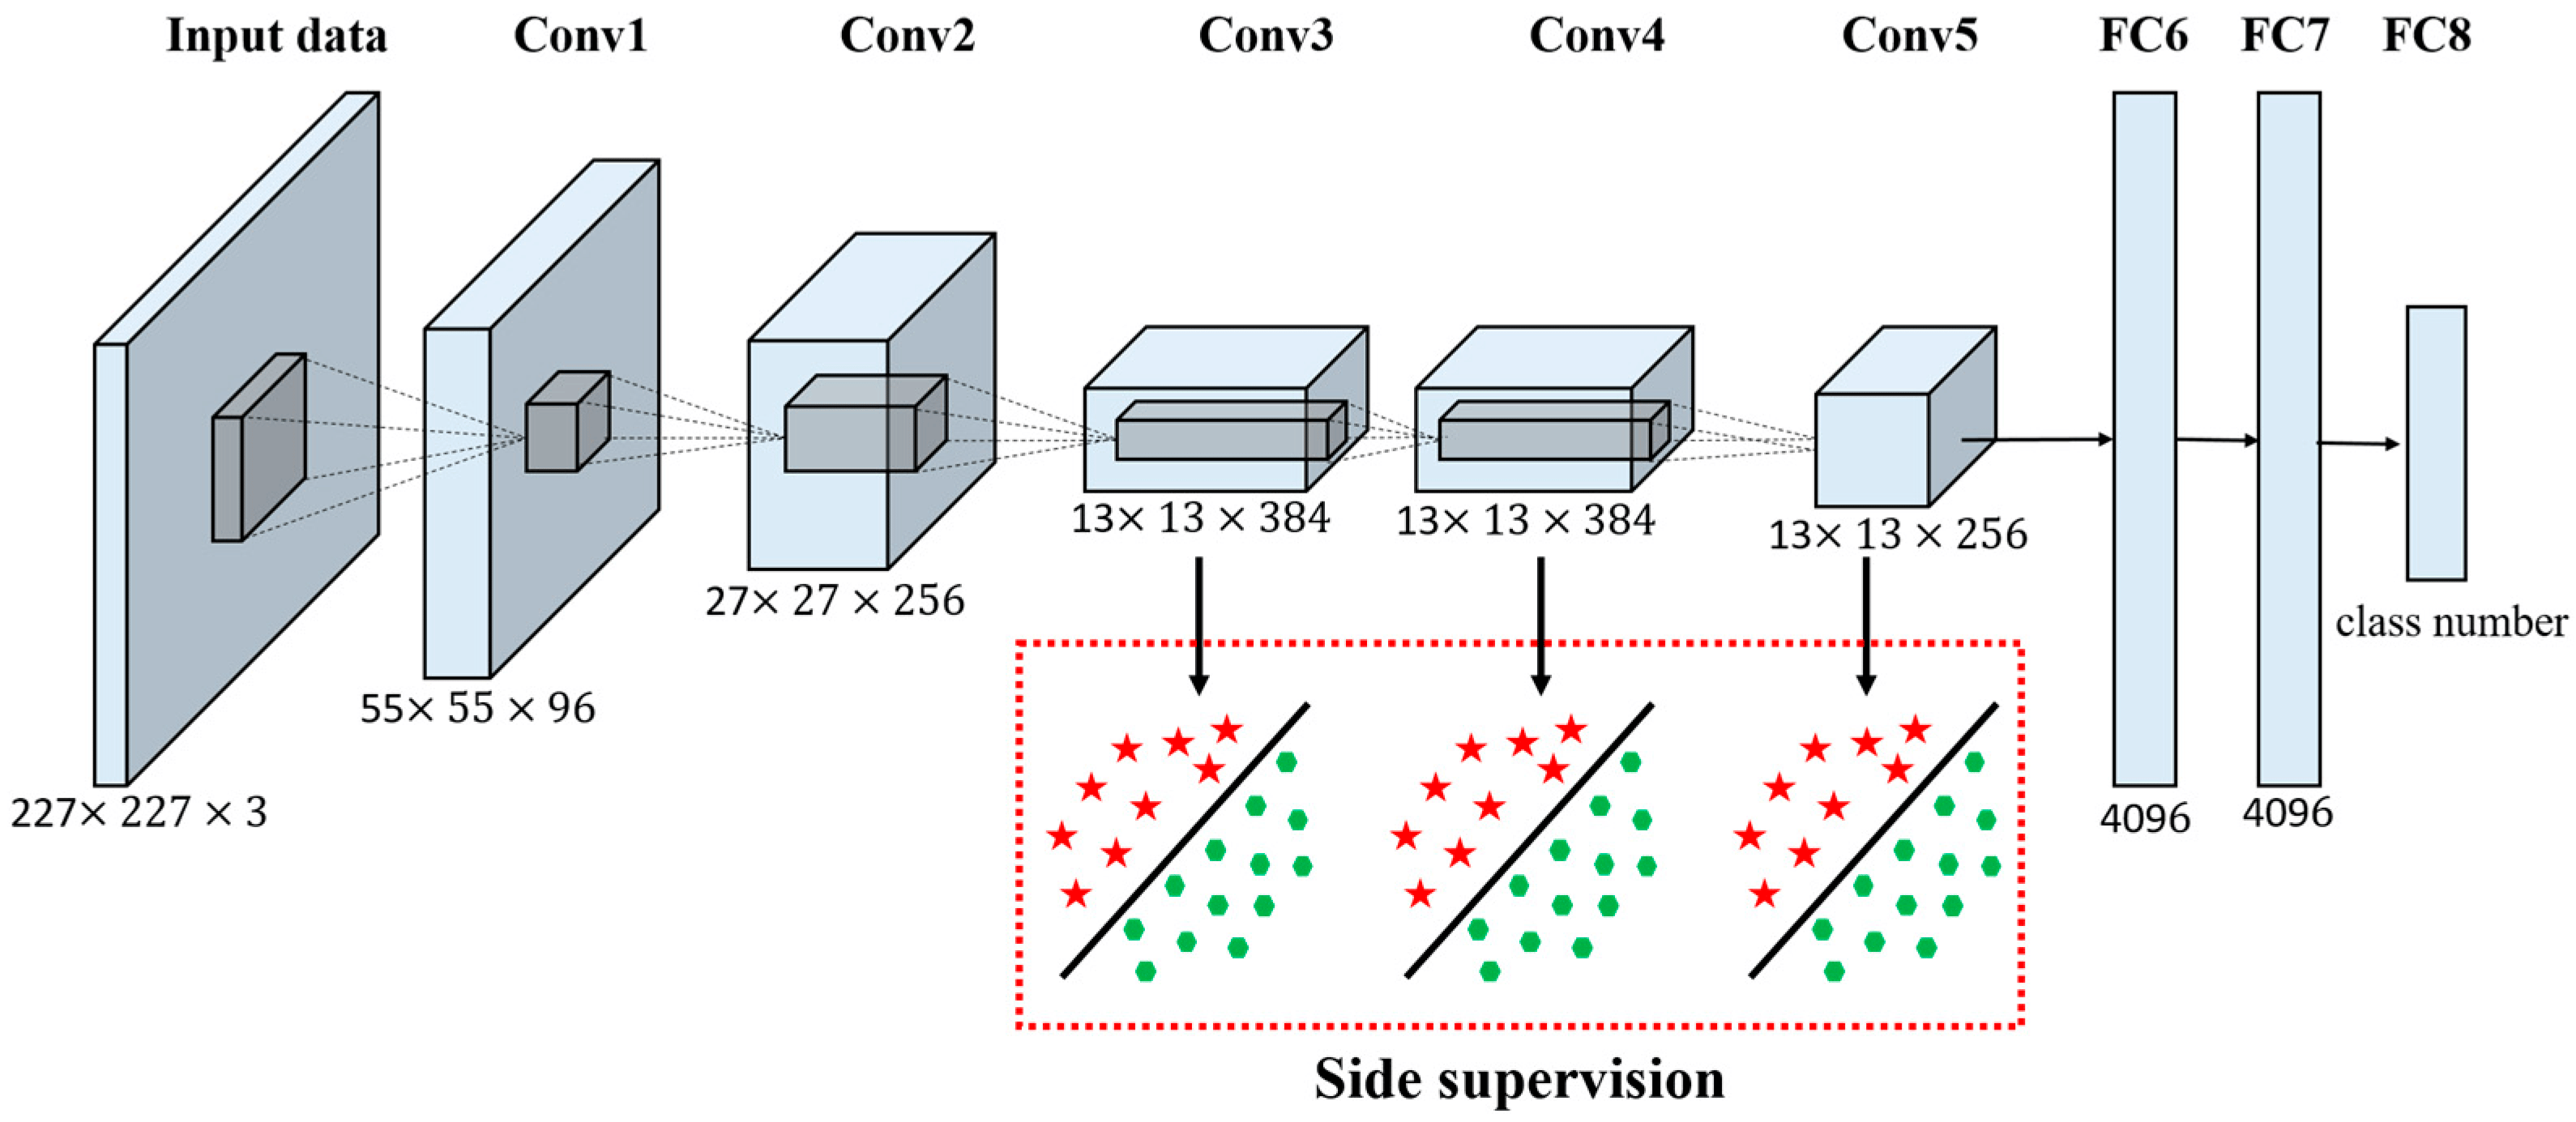

In [12]:
class AlexNet(nn.Module):
    """
    AlexNet model for image classification, modified for CIFAR-10.
    Architecture:
    - 5 Convolutional layers with ReLU and max pooling
    - 3 Fully connected layers
    - Output: 10 classes
    """
    def __init__(self):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 4096),  # Adjusted for CIFAR-10 input size
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(-1, 256 * 4 * 4)
        x = self.classifier(x)
        return x


In [13]:
# Define training and evaluation functions
def train(model, device, train_loader, optimizer, criterion, epochs=10):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {total_loss / len(train_loader):.4f}")

def test(model, device, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    accuracy = 100 * correct / total
    print(f"Accuracy: {accuracy:.2f}%")
    return accuracy



Loading CIFAR-10 from Google Drive (no torchvision download)

Uses the **CIFAR-10 python version** (`cifar-10-python.tar.gz`, 163 MB, md5 `c58f30108f718f92721af3b95e74349a`).
Set `DRIVE_TAR` to wherever the archive sits in your Drive. The `CIFAR10Local` class below is a drop-in
replacement for `datasets.CIFAR10` — same `__getitem__` contract, same `classes` / `class_to_idx`.

In [ ]:
import os, pickle, tarfile
import numpy as np
from PIL import Image

# ---- Mount Google Drive (skip if running locally) ----
try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print("Not on Colab - make sure DRIVE_TAR points to a local path")

# ---- Path to the CIFAR-10 *python version* archive in your Drive ----
DRIVE_TAR   = '/content/drive/MyDrive/cifar-10-python.tar.gz'
EXTRACT_DIR = './data'

# ---- Extract once (guarded, so re-running is cheap) ----
data_root = os.path.join(EXTRACT_DIR, 'cifar-10-batches-py')
if not os.path.isdir(data_root):
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with tarfile.open(DRIVE_TAR, 'r:gz') as tar:
        tar.extractall(EXTRACT_DIR)
print("Data at:", data_root, "->", sorted(os.listdir(data_root)))

def _unpickle(path):
    with open(path, 'rb') as f:
        return pickle.load(f, encoding='bytes')

class CIFAR10Local(torch.utils.data.Dataset):
    """Drop-in replacement for torchvision.datasets.CIFAR10 that reads the
    extracted python-version batch files instead of downloading."""
    def __init__(self, root, train=True, transform=None):
        self.transform = transform
        files = [f'data_batch_{i}' for i in range(1, 6)] if train else ['test_batch']

        imgs, labels = [], []
        for fname in files:
            d = _unpickle(os.path.join(root, fname))
            imgs.append(d[b'data'])
            labels += d[b'labels']

        # (N, 3072) flat -> (N, 32, 32, 3) HWC uint8
        self.data = np.concatenate(imgs).reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
        self.targets = labels

        meta = _unpickle(os.path.join(root, 'batches.meta'))
        self.classes = [c.decode('utf-8') for c in meta[b'label_names']]
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        img = Image.fromarray(self.data[idx])      # PIL, same as torchvision
        if self.transform is not None:
            img = self.transform(img)
        return img, self.targets[idx]


In [ ]:
# Prepare dataset and loaders
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = CIFAR10Local(data_root, train=True,  transform=transform)
test_dataset  = CIFAR10Local(data_root, train=False, transform=transform)
print(len(train_dataset), "train images |", len(test_dataset), "test images")

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize models, criterion, and optimizers
lenet = LeNet5().to(device)
alexnet = AlexNet().to(device)

criterion = nn.CrossEntropyLoss()
lenet_optimizer = optim.Adam(lenet.parameters(), lr=0.001)
alexnet_optimizer = optim.Adam(alexnet.parameters(), lr=0.001)

# Train and evaluate LeNet-5
print("Training LeNet-5")
train(lenet, device, train_loader, lenet_optimizer, criterion, epochs=5)
lenet_accuracy = test(lenet, device, test_loader)

# Train and evaluate AlexNet
print("Training AlexNet")
train(alexnet, device, train_loader, alexnet_optimizer, criterion, epochs=5)
alexnet_accuracy = test(alexnet, device, test_loader)



In [15]:
# Comparison
print("\nComparison:")
print(f"LeNet-5 Accuracy: {lenet_accuracy:.2f}%")
print(f"AlexNet Accuracy: {alexnet_accuracy:.2f}%")


Comparison:
LeNet-5 Accuracy: 60.52%
AlexNet Accuracy: 70.89%
